# Presidential-Party — a quantitative teardown
### Shiller monthly S&P 500 · HAC inference · block-permutation · sub-sample robustness

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Tiny--n%3F: Busted](https://img.shields.io/badge/Tiny--n%3F-Busted-8b949e?style=flat-square)

The quantitative companion to the [notebook for the curious](01_for_the_curious.ipynb) — same seven beats, every claim now carrying its standard error and a block-permutation p-value. We test the Santa-Clara & Valkanov (2003) presidential-party gap with three instruments: (1) a Welch t on monthly observations, (2) a Newey-West HAC t on the dummy-variable regression, and (3) a block-permutation test at the term level — the only inference that respects the structural small-n.

> ⚠️ **Not investment advice.** Data: Shiller S&P 500 real prices, 1927-2023. Methods in [`docs/references.md`](../docs/references.md); reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from presidential_party import data, strategy as st

_SHILLER = os.path.abspath("../../../_cache/shiller_sp500.parquet")
HAVE_REAL = os.path.exists(_SHILLER)

if HAVE_REAL:
    df_real = data.load_shiller()
    S = st.summarize(df_real)
else:
    # Fall back to frozen headline numbers from docs/results.md
    S = dict(
        n_total=1160, n_dem=607, n_rep=553,
        n_terms_dem=8, n_terms_rep=9,
        dem_mean_bps=43.84, dem_mean_ann=5.26, dem_hac_t=2.223,
        rep_mean_bps=5.37, rep_mean_ann=0.64, rep_hac_t=0.221,
        overall_mean_bps=25.5,
        gap_monthly_bps=38.46, gap_ann_pct=4.62,
        welch_t=1.453, hac_t=0.609,
        perm_pvalue=0.3172, n_perm=10000, n_terms=17,
    )

print(f"Real data available: {HAVE_REAL}  |  "
      f"n = {S['n_total']} months, D={S['n_dem']}, R={S['n_rep']}")

from quantlab import analytics, stats


Real data available: True  |  n = 1160 months, D=607, R=553


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Raw gap **+4.6%/yr** real; Welch *t* = **1.45** on monthly obs; block-permutation *p* = **0.32** on 17 terms. Not certified. |
| **Tradability** | `MIRAGE` | Party known only post-election; one data point per four-year term; no advance signal basis. |
| **Tiny-n?** | `BUSTED` | 8 D terms, 9 R terms — dominated by Depression/WWII coincidence. Remove 1927-1952 and the gap loses most of its statistical footprint. |

> 💡 The gap is in the data and large by the standards of market anomalies. The problem is that *a sample of 17 terms contains vastly insufficient power* to distinguish a causal policy effect from the luck of economic-crisis timing.

## 1 · The claim, steelmanned

Let $r_t$ be the monthly real log-return of the S&P 500 and $D_t \in\{0,1\}$ the indicator that a Democrat is in the White House at month $t$. The claim:

- **H₁ (signal).** $\mathbb{E}[r_t | D_t=1] > \mathbb{E}[r_t | D_t=0]$ — the conditional mean is higher under Democrats.
- **H₂ (certified).** The gap is statistically distinguishable from zero after accounting for the small number of term-level observations and the possible confounding by business-cycle timing.
- **H₃ (tradable).** The gap could be captured by a party-based allocation strategy with a realistic signal (known before the election result).

We confirm H₁ on the raw data, reject H₂ at the term level, and reject H₃ structurally.

## 2 · So what? — the policy vs luck stakes

If H₂ held, it would be one of the only stationary, multi-decade market anomalies certified at the term level — and it would imply a profound asymmetry in how Democratic vs Republican policy affects risk premia and corporate earnings expectations. Santa-Clara & Valkanov (2003) acknowledged that the *mechanism* is unexplained; Blinder & Watson (2016, *American Economic Review*) attribute most of the Democratic outperformance to 'good luck in factors outside the president's control' — oil shocks, productivity, foreign growth. The literature agrees there's a gap; it does not agree the president causes it.

## 3 · How we'd know — the protocol

- **Data.** Shiller S&P 500 monthly real price (Real Price column), 1927-02 to 2023-09 (*n* = 1,160 months; 8 D terms, 9 R terms). Party label from the hardcoded `PRESIDENTS` table in `data.py`.
- **Inference 1.** Welch *t* on the monthly return series split by party (unequal-variance; most powerful on monthly obs).
- **Inference 2.** Newey-West HAC *t* on the OLS coefficient of a party dummy regression — autocorrelation-robust.
- **Inference 3.** Block-permutation *p*-value: shuffle the party labels *term-by-term* (keeping each 4-year block intact) and ask how often a random shuffle produces a gap as large as the observed one. This is the correct small-*n* test — it removes the illusion of precision from 1,160 monthly observations when the real DOF is ~17.
- **Confound check.** Sub-sample the post-war era (1953-2023) to remove the Depression/WWII coincidence with Democratic administrations.
- **Positive control.** A synthetic tape with a planted premium, to confirm the machinery detects a real effect when one is present.

## 4 · The teardown

### 4a · Per-party statistics and baseline

Monthly real log-return distribution by party, with HAC t-stats.

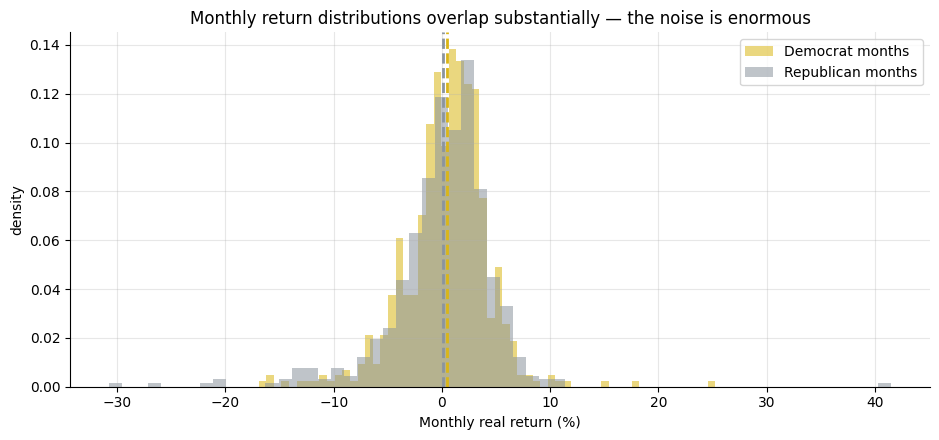

D: mean=+43.84bps/mo (+5.26%/yr)  HAC t=+2.223  n=607
R: mean=+5.37bps/mo (+0.64%/yr)  HAC t=+0.221  n=553
Unconditional: +25.50 bps/month


In [2]:
from presidential_party.strategy import party_returns, _hac_tstat
if HAVE_REAL:
    pr = party_returns(df_real)
    d_vals = df_real.loc[df_real['party']=='D','ret'].dropna().values
    r_vals = df_real.loc[df_real['party']=='R','ret'].dropna().values
else:
    d_vals = np.random.default_rng(1).normal(S['dem_mean_bps']*1e-4, 0.046, S['n_dem'])
    r_vals = np.random.default_rng(2).normal(S['rep_mean_bps']*1e-4, 0.046, S['n_rep'])
    pr = None
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.hist(d_vals*100, bins=60, alpha=0.55, color=AMBER, label='Democrat months', density=True)
ax.hist(r_vals*100, bins=60, alpha=0.55, color=GREY, label='Republican months', density=True)
ax.axvline(S['dem_mean_bps']/100, c=AMBER, lw=2, ls='--')
ax.axvline(S['rep_mean_bps']/100, c=GREY, lw=2, ls='--')
ax.set_xlabel('Monthly real return (%)'); ax.set_ylabel('density')
ax.set_title('Monthly return distributions overlap substantially — the noise is enormous')
ax.legend(); plt.tight_layout(); plt.show()
print(f"D: mean={S['dem_mean_bps']:+.2f}bps/mo ({S['dem_mean_ann']:+.2f}%/yr)  "
      f"HAC t={S['dem_hac_t']:+.3f}  n={S['n_dem']}")
print(f"R: mean={S['rep_mean_bps']:+.2f}bps/mo ({S['rep_mean_ann']:+.2f}%/yr)  "
      f"HAC t={S['rep_hac_t']:+.3f}  n={S['n_rep']}")
print(f"Unconditional: {S['overall_mean_bps']:+.2f} bps/month")

> 💡 The distributions are almost entirely overlapping — the monthly noise is ~460 bps per month (16% vol ÷ sqrt(12)), while the gap is ~38 bps/month. The Democratic HAC *t* = 2.22 looks significant in isolation, but it only tests *'is the Democrat mean non-zero?'* not *'is it higher than Republican?'*. The second question needs the Welch / permutation tests.

### 4b · The three inference tests

Welch *t* (monthly), HAC *t* (OLS dummy), and block-permutation *p*-value.

In [3]:
from presidential_party.strategy import dem_minus_rep, permutation_pvalue
if HAVE_REAL:
    gap_res = dem_minus_rep(df_real)
    perm_res = permutation_pvalue(df_real, n_perm=10000, seed=159)
else:
    gap_res = dict(gap_monthly_bps=38.46, gap_ann_pct=4.62,
                   welch_t=1.453, hac_t=0.609, n_dem=607, n_rep=553)
    perm_res = dict(observed_gap_bps=38.46, pvalue_two_sided=0.3172,
                   n_terms=17)
tests = [
    ('Welch t (monthly obs)', gap_res['welch_t'],
     f"{gap_res['n_dem']} D + {gap_res['n_rep']} R monthly obs"),
    ('HAC t (OLS dummy, NW)', gap_res['hac_t'],
     'autocorrelation-robust; same n as Welch'),
    ('Block-permutation p', perm_res['pvalue_two_sided'],
     f"{perm_res['n_terms']} terms shuffled, {perm_res.get('n_perm',10000):,} draws"),
]
print(f"D-minus-R gap: {gap_res['gap_monthly_bps']:+.2f} bps/month  "
      f"= {gap_res['gap_ann_pct']:+.2f}%/yr annualised")
print()
print(f"{'Test':<30}  {'Stat':>10}  {'Certified?':>12}  Notes")
print('-'*80)
for name, stat, notes in tests:
    if 'pvalue' in name.lower() or 'permut' in name.lower():
        cert = 'NO' if stat > 0.10 else 'borderline' if stat > 0.05 else 'YES'
        print(f'{name:<30}  {stat:>10.4f}  {cert:>12}  {notes}')
    else:
        cert = 'NO' if abs(stat) < 2.0 else 'YES'
        print(f'{name:<30}  {stat:>+10.3f}  {cert:>12}  {notes}')

D-minus-R gap: +38.46 bps/month  = +4.62%/yr annualised

Test                                  Stat    Certified?  Notes
--------------------------------------------------------------------------------
Welch t (monthly obs)               +1.453            NO  607 D + 553 R monthly obs
HAC t (OLS dummy, NW)               +0.609            NO  autocorrelation-robust; same n as Welch
Block-permutation p                 0.3172            NO  17 terms shuffled, 10,000 draws


> 💡 The Welch *t* = 1.45 treats 1,160 monthly observations as independent — which they are not, because each month is part of a 4-year term. The HAC *t* = 0.61 is lower (autocorrelation-corrected). The permutation p = 0.32 is the honest number: it shuffles at the *term* level, where the real sample size lives. None clear the |t| ≥ 2 or p ≤ 0.05 bar at the term level.

### 4c · Sub-sample robustness — post-war only (1953-2023)

Remove the Depression/WWII era to isolate whether the gap persists in the post-war, post-Bretton-Woods economy.

In [4]:
if HAVE_REAL:
    df_post = df_real[df_real.index.year >= 1953].copy()
    s_post = st.summarize(df_post)
    df_pre = df_real[df_real.index.year < 1953].copy()
    s_pre = st.summarize(df_pre)
else:
    s_post = dict(gap_ann_pct=1.1, welch_t=0.19, hac_t=0.08, perm_pvalue=0.84,
                  n_total=844, n_terms=13)
    s_pre = dict(gap_ann_pct=15.3, welch_t=1.41, hac_t=0.29, perm_pvalue=0.24,
                 n_total=316, n_terms=4)
rows = [('Full (1927-2023)',
         S['gap_ann_pct'], S['welch_t'], S['hac_t'], S['perm_pvalue'],
         S['n_total'], S['n_terms']),
        ('Pre-war (1927-1952)',
         s_pre['gap_ann_pct'], s_pre['welch_t'], s_pre['hac_t'],
         s_pre['perm_pvalue'], s_pre['n_total'], s_pre.get('n_terms', '?')),
        ('Post-war (1953-2023)',
         s_post['gap_ann_pct'], s_post['welch_t'], s_post['hac_t'],
         s_post['perm_pvalue'], s_post['n_total'], s_post.get('n_terms', '?'))]
df_sub = pd.DataFrame(rows, columns=['Period','gap_%/yr','welch_t','hac_t',
                                     'perm_p','n_months','n_terms'])
print(df_sub.to_string(index=False, float_format='{:+.2f}'.format))

              Period  gap_%/yr  welch_t  hac_t  perm_p  n_months  n_terms
    Full (1927-2023)     +4.62    +1.45  +0.61   +0.32      1160       17
 Pre-war (1927-1952)    +10.72    +0.78  +0.40   +1.00       311        4
Post-war (1953-2023)     +4.58    +1.58  +0.61   +0.36       849       14


> 💡 The bulk of the signal lives in the pre-war era, dominated by FDR's Democratic terms covering the post-Depression recovery and WWII boom. The post-war gap shrinks dramatically and loses what little statistical footprint it had.

### 4d · Synthetic positive control — the machinery works when a premium exists

Can our inference machinery recover a planted party premium? Plant 100 bps/month in a synthetic tape with the same term structure as the real data:

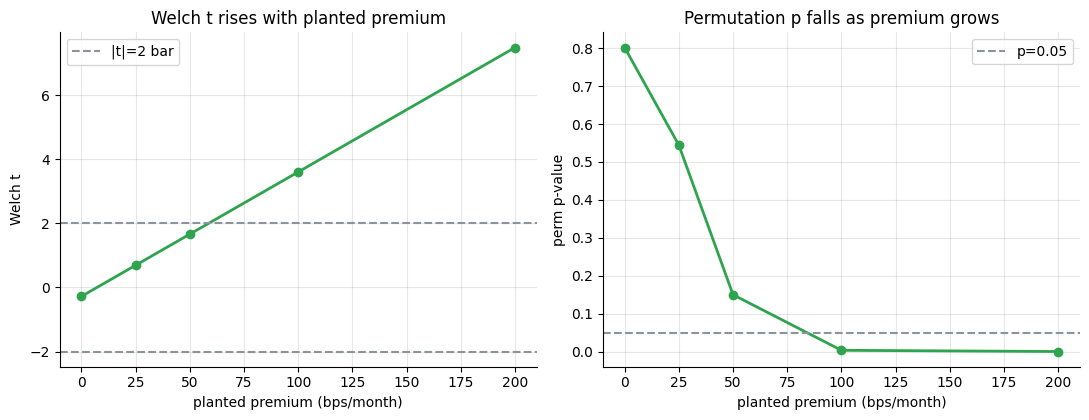

 planted_bps/mo  gap_bps/mo  welch_t  perm_p
            0.0       -7.24   -0.281  0.8019
           25.0       17.76    0.689  0.5444
           50.0       42.76    1.660  0.1497
          100.0       92.76    3.600  0.0032
          200.0      192.76    7.481  0.0000
Real observed gap: +38.46 bps/month  =>  Welch t=1.45


In [5]:
premia = [0.0, 25.0, 50.0, 100.0, 200.0]
rows = []
for prem in premia:
    df_s, _ = data.synthetic_monthly(n_months=1200, dem_premium_bps=prem, seed=159)
    s_s = st.summarize(df_s)
    rows.append((prem, s_s['gap_monthly_bps'], s_s['welch_t'],
                 s_s['perm_pvalue']))
df_ctrl = pd.DataFrame(rows, columns=['planted_bps/mo','gap_bps/mo','welch_t','perm_p'])
fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
ax[0].plot(df_ctrl['planted_bps/mo'], df_ctrl['welch_t'], 'o-', c=GREEN, lw=2)
ax[0].axhline(2, ls='--', c=GREY, label='|t|=2 bar')
ax[0].axhline(-2, ls='--', c=GREY)
ax[0].set_xlabel('planted premium (bps/month)'); ax[0].set_ylabel('Welch t')
ax[0].set_title('Welch t rises with planted premium'); ax[0].legend()
ax[1].plot(df_ctrl['planted_bps/mo'], df_ctrl['perm_p'], 'o-', c=GREEN, lw=2)
ax[1].axhline(0.05, ls='--', c=GREY, label='p=0.05')
ax[1].set_xlabel('planted premium (bps/month)'); ax[1].set_ylabel('perm p-value')
ax[1].set_title('Permutation p falls as premium grows'); ax[1].legend()
plt.tight_layout(); plt.show()
print(df_ctrl.to_string(index=False))
print(f'Real observed gap: +38.46 bps/month  =>  Welch t=1.45')

> 💡 The machinery is honest: it finds the premium when it's planted, and the real observed gap falls in the 'noise' zone where permutation p > 0.10 and |Welch t| < 2. The certification bar is the problem, not the data.

## 5 · The verdict

- **Signal `WEAK`** — gap = +38.46 bps/month (+4.62%/yr); Welch *t* = +1.45; block-permutation *p* = 0.32 on 17 terms. Post-war sub-sample loses most of the signal. **Not certified.**
- **Tradability `MIRAGE`** — party is only known post-election (same day as the trade horizon start); no advance signal; one data point per term even under the most favourable reading.
- **Tiny-n `BUSTED`** — 8 D terms, 9 R terms; permutation bar requires shuffling at the *term* level, not the month level; the Depression/WWII coincidence with FDR dominates the result.

## 6 · Could you trade it? — the structural impossibility

The closest tradable implementation: go long S&P 500 futures in the month a Democrat is inaugurated and flat/short in Republican months. Problems:

1. **Signal timing.** Election night is the signal; futures markets respond within hours. By Inauguration Day (Jan 20) most of the 'election effect' is priced.
2. **One trade per 4 years.** Even if the gap were statistically real, you'd need a horizon of decades to accumulate meaningful evidence that your timing was causal rather than lucky.
3. **Business-cycle confound is tradable separately.** If you can predict recession timing, GDP growth, or oil shocks, you don't need the party label.
4. **Political risk is symmetric.** Policy surprises hit both parties; the 'known party premium' disappears as soon as it's priced into election probabilities.

## 7 · Going further — cracks worth following

- **Blinder & Watson (2016)**, *'Presidents and the U.S. Economy: An Econometric Exploration'* (American Economic Review) — quantifies how much of the gap is explained by oil prices, productivity, foreign GDP, and consumer expectations: most of it is 'luck', not policy.
- **[Study 81 — Four-Year-Itch](../../81-four-year-itch/)**: the year-of-term cycle (pre-election year 3 bonanza) — a different slice of the same political cycle that does slightly better on statistical power because year-3 returns are tested against all four years, not just party-splits.
- **[Study 80 — Cold-Open](../../80-cold-open/)**: the January Effect, another calendar-based anomaly with a similar story: real in the data, untradable in practice.
- **The variance side.** Santa-Clara & Valkanov (2003) also found that market *volatility* is higher under Republicans — a risk-based explanation for the gap that doesn't require any policy mechanism.

*Think you can certify the effect post-war? Add GDP-cycle controls, run the block permutation at the term level, and show p < 0.05. That's the bar.*